# Common Libraries

In [1]:
import os, sys, shutil, mediapy
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pylab as plt
from ipywidgets import interact

if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"
import mujoco

# Custom Libraries

In [2]:
def get_indices(model, joint_name):
    jnt_id = model.joint(joint_name).id
    qpos_idx = model.jnt_qposadr[jnt_id]
    dof_idx = model.jnt_dofadr[jnt_id]
    return qpos_idx, dof_idx

In [12]:
def get_qfrc(model, data, target_qpos):
    """
    Compute the generalized force needed to reach the target position in the next mujoco step.
    """
    data_copy = mujoco.MjData(model)
    data_copy.qpos = data.qpos.copy()
    data_copy.qvel = data.qvel.copy()
    data_copy.qacc = (((target_qpos - data.qpos) / model.opt.timestep) - data.qvel) / model.opt.timestep
    model.opt.disableflags += mujoco.mjtDisableBit.mjDSBL_CONSTRAINT
    mujoco.mj_inverse(model, data_copy)
    model.opt.disableflags -= mujoco.mjtDisableBit.mjDSBL_CONSTRAINT
    return data_copy

# Params

In [13]:
model_path = "/home/seojin/biomechanics_tools/myo_sim/arm/myoarm.xml"
n_sim = 1000
sim_interval = 1 / n_sim

# Initialize model

In [14]:
model = mujoco.MjModel.from_xml_path(model_path)
model.opt.timestep = sim_interval

# Model constants
joint_names = [mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, idx) for idx in range(model.njnt)]
n_joint = len(joint_names)

# Joint indexing
shoulder_elevation_angle_q, shoulder_elevation_angle_d = get_indices(model, "shoulder_elv")

# Initialize pose
mj_data = mujoco.MjData(model)
mujoco.mj_forward(model, mj_data)

# Renderer

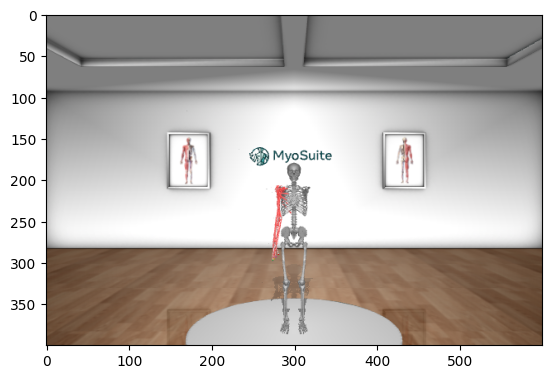

In [15]:
# Renderer
renderer = mujoco.Renderer(model, height=400, width=600)
scene_option = mujoco.MjvOption()
scene_option.frame = mujoco.mjtFrame.mjFRAME_WORLD

# Camera
camera = mujoco.MjvCamera()
camera.azimuth = 90
camera.elevation = 0
camera.distance = 4
camera.lookat = [0,0,1.5]

# Initial render
renderer.update_scene(mj_data, camera=camera, scene_option=scene_option)
plt.imshow(renderer.render())

# Goal

In [16]:
final_goal_qpos = np.zeros(n_joint)
final_goal_qpos[shoulder_elevation_angle_q] = 1.6

goal_qpos = np.zeros((n_sim, n_joint))
goal_qpos[:, shoulder_elevation_angle_q] = np.linspace(0.0, final_goal_qpos[shoulder_elevation_angle_q], n_sim)

In [17]:
# Initialize start pose
mj_data = mujoco.MjData(model)
mujoco.mj_forward(model, mj_data)

# Image
pixels = np.zeros((n_sim, renderer.height, renderer.width, 3), dtype = np.uint8)

# Force
qforces = pd.DataFrame(np.zeros((n_sim, n_joint)))
qforces.columns = joint_names

# Error
qerrors = pd.DataFrame(np.zeros((n_sim, n_joint)))
qerrors.columns = joint_names

# Simulation
for sim_i in tqdm(range(n_sim)):
    # Current
    current_qpos = mj_data.qpos.copy()
    current_qvel = mj_data.qvel.copy()
    
    # Control
    error_q = np.zeros(n_joint)
    error_q[shoulder_elevation_angle_q] = goal_qpos[sim_i, shoulder_elevation_angle_q] - current_qpos[shoulder_elevation_angle_q]
    qerrors.iloc[sim_i] = error_q

    # mj inverse
    force_data = get_qfrc(model, mj_data, goal_qpos[sim_i])
    mj_data.qfrc_applied[:] = force_data.qfrc_inverse
    qforces.iloc[sim_i] = force_data.qfrc_inverse

    # Forward dyanmics
    mujoco.mj_step(model, mj_data)

    # Rendering
    renderer.update_scene(mj_data, camera = camera, scene_option = scene_option)
    pixels[sim_i] = renderer.render()

100%|██████████| 1000/1000 [00:06<00:00, 145.74it/s]


In [18]:
mediapy.show_video(pixels, fps = 30, loop=False)

This browser does not support the video tag.


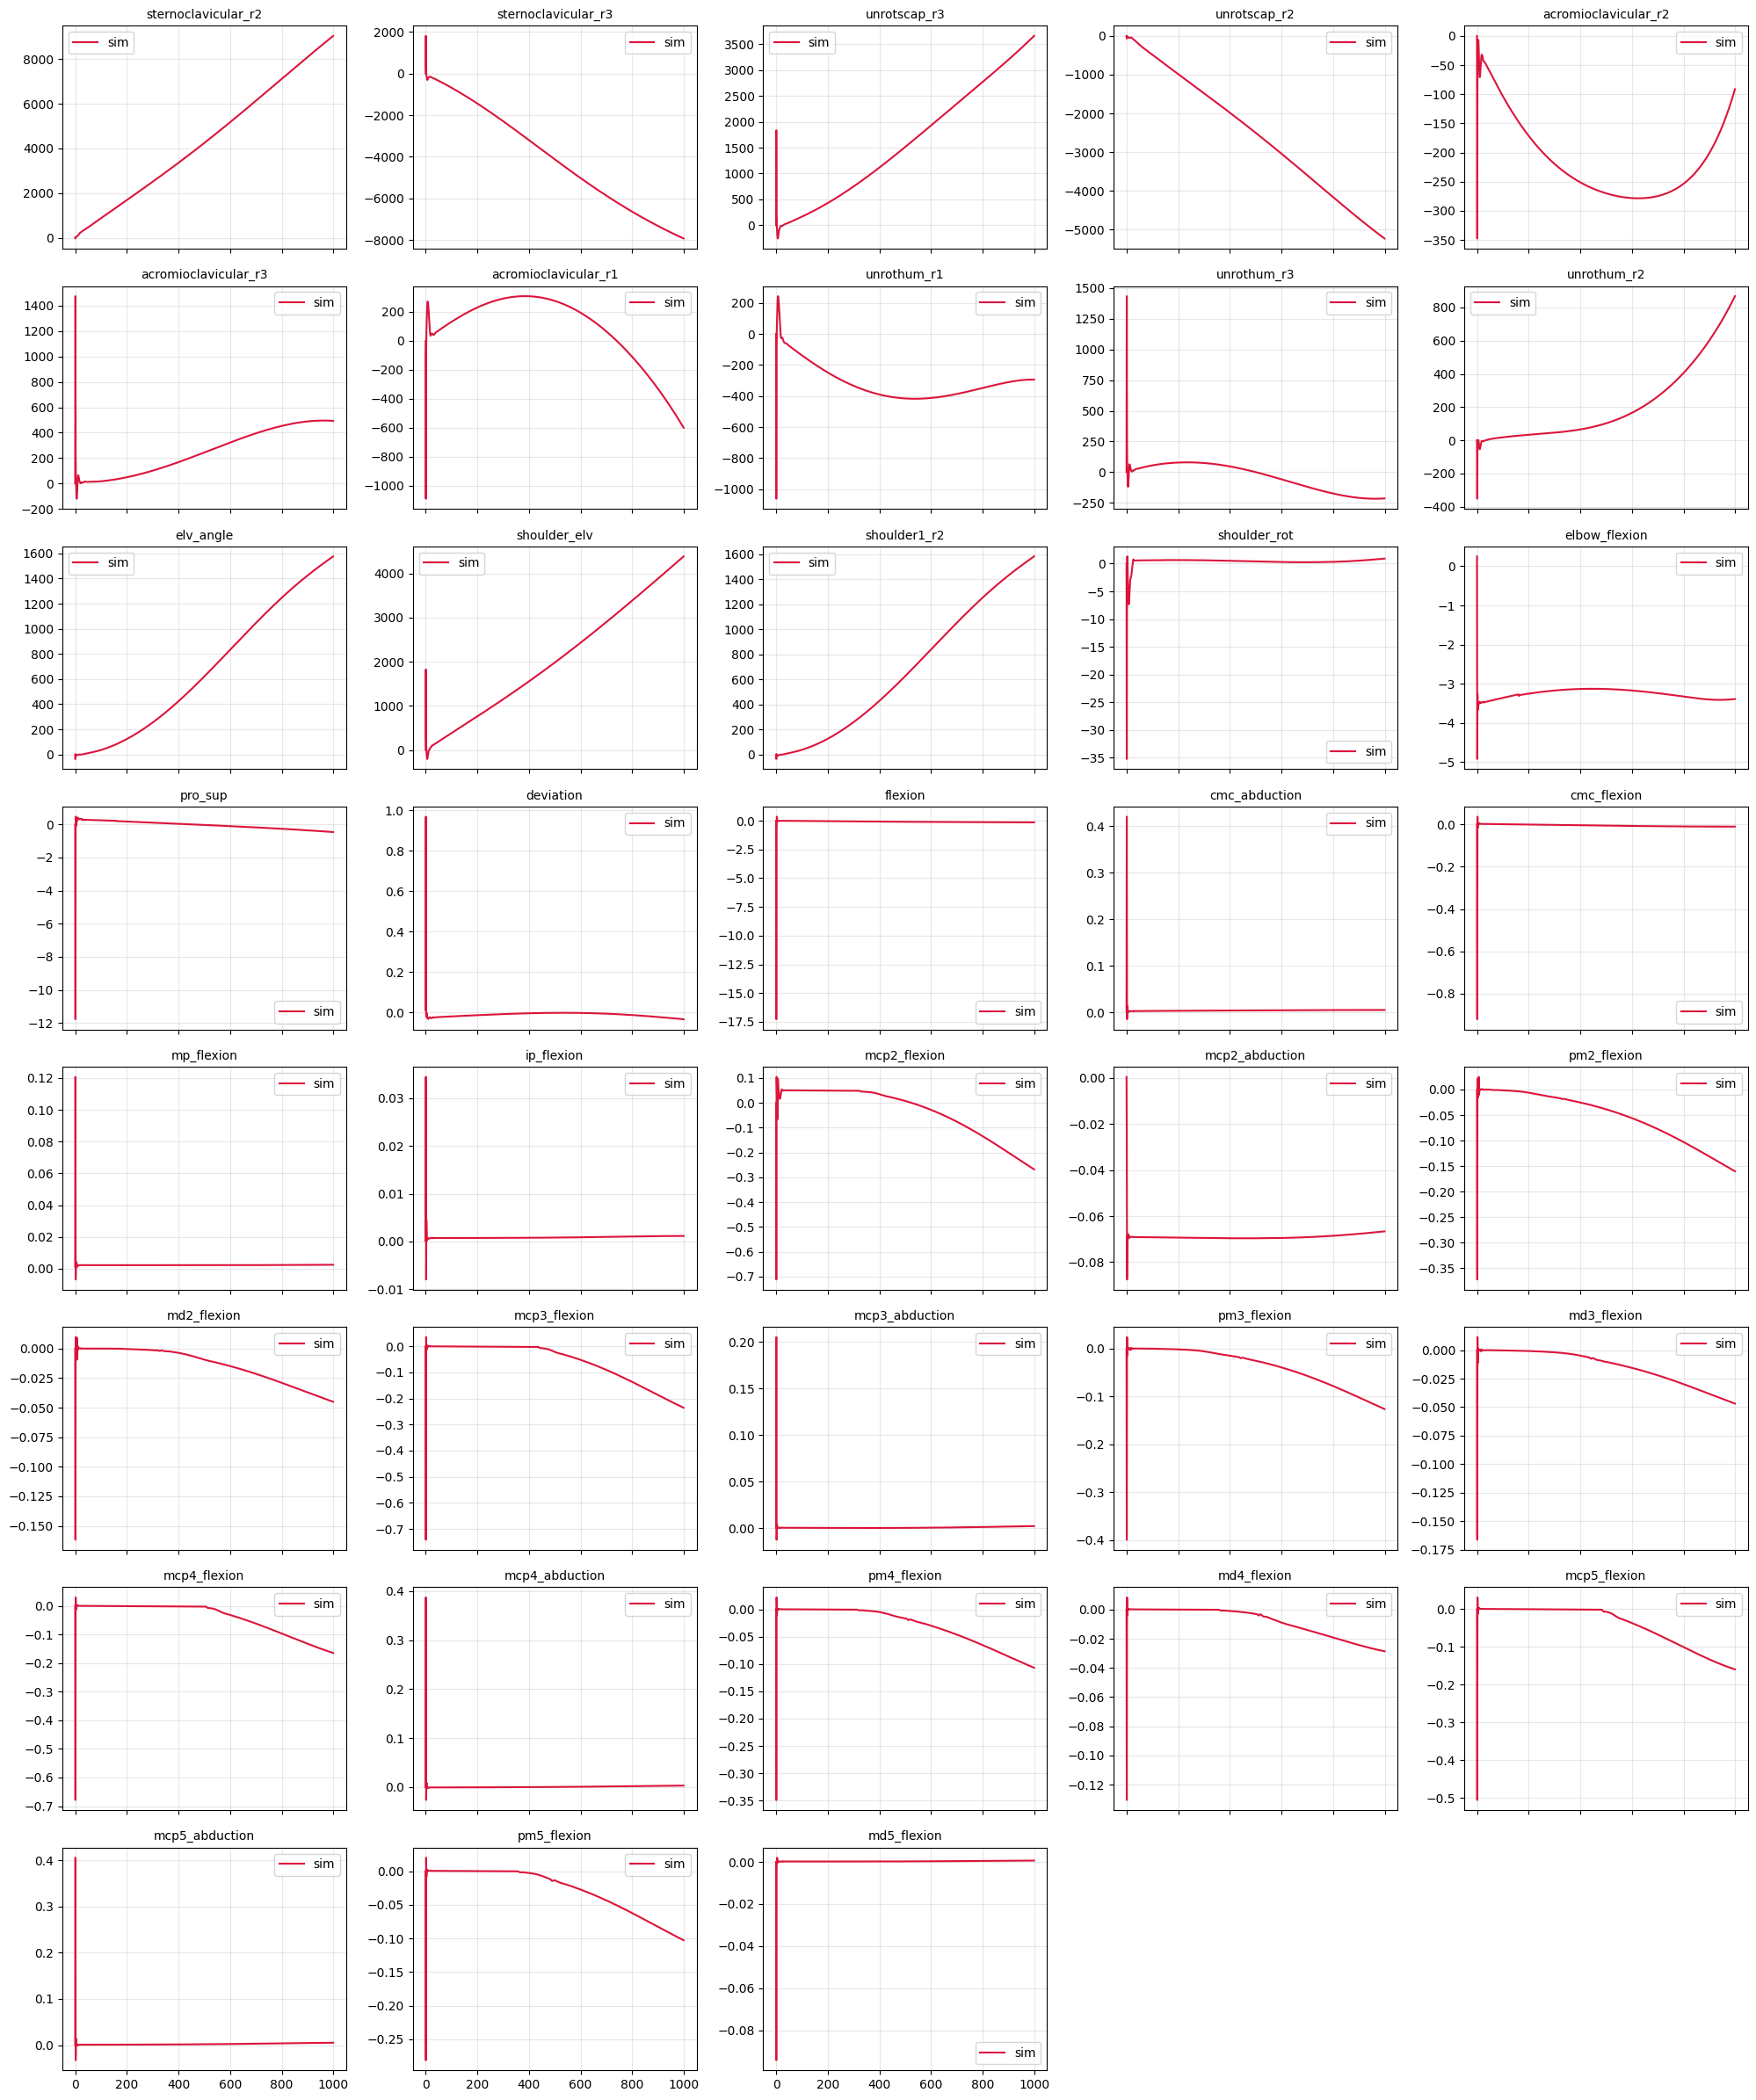

In [19]:
# Plot parameters
n_cols = 5
n_rows = (len(joint_names) + n_cols - 1) // n_cols

# Plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3), sharex=True)
axes = axes.flatten()
for i, joint_name in enumerate(joint_names):
    ax = axes[i]
    ax.plot(np.arange(0, n_sim), qforces[joint_name], color = "crimson", lw = 1.5, label = "sim")
    ax.set_title(joint_name, fontsize = 10)
    ax.grid(alpha = 0.3)
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()